In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
CSV_DIR = "../cross_validation_output/"

Sequential Node IT V2 DataFrame:
   TOTAL_DURATION_US
0              54806
   NUM_THREADS  TOTAL_DURATION_US
0            2              54806
1            4              54806
2            6              54806
3            8              54806
4           10              54806
5           16              54806
6           24              54806


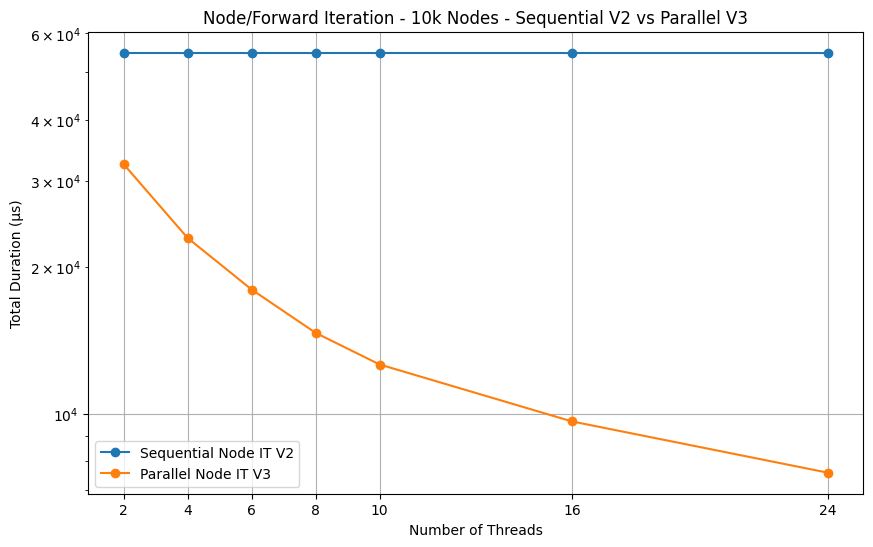

In [ ]:
#chart multiseries - Node
SEQ_NODE_IT_V2 = CSV_DIR + "seq_node_it_v2/graph_10k_RTX_4060_M.csv"
PARALLEL_NODE_IT_V2 = CSV_DIR + "parallel_node_it_v2/graph_10k_RTX_4060_M.csv"
PARALLEL_NODE_IT_V3 = CSV_DIR + "parallel_node_it_v3/graph_10k_RYZEN_7_7435_HS.csv"
CUDA_NODE_IT_V2 = CSV_DIR + "cuda_node_it_v2/graph_10k_RTX_4060_M.csv"

desired_cols = ['NUM_THREADS', 'TOTAL_DURATION_US']
fig = plt.figure(figsize=(10, 6))
seq_node_it_v2_df = pd.read_csv(SEQ_NODE_IT_V2, usecols=['TOTAL_DURATION_US'])
parallel_node_it_v3_df = pd.read_csv(PARALLEL_NODE_IT_V3, usecols=desired_cols)
parallel_node_it_v2_df = pd.read_csv(PARALLEL_NODE_IT_V2, usecols=desired_cols)

print("Sequential Node IT V2 DataFrame:")
print(seq_node_it_v2_df)
#FOR sequential put a straight line
num_threads_list = [2, 4, 6, 8, 10, 16, 24]
duration_sttraight_line = seq_node_it_v2_df['TOTAL_DURATION_US'].iloc[0]
seq_node_it_v2_df_extended = pd.DataFrame({
    'NUM_THREADS': num_threads_list,
    'TOTAL_DURATION_US': [duration_sttraight_line] * len(num_threads_list)
})
print(seq_node_it_v2_df_extended)
plt.plot(seq_node_it_v2_df_extended['NUM_THREADS'], seq_node_it_v2_df_extended['TOTAL_DURATION_US'], label='Sequential Node IT V2', marker='o')
plt.plot(parallel_node_it_v3_df['NUM_THREADS'], parallel_node_it_v3_df['TOTAL_DURATION_US'], label='Parallel Node IT V3', marker='o')
#plt.plot(parallel_node_it_v2_df['NUM_THREADS'], parallel_node_it_v2_df['TOTAL_DURATION_US'], label='Parallel Node IT V2', marker='o')
plt.title('Node/Forward Iteration - 10k Nodes - Sequential V2 vs Parallel V3')
plt.xlabel('Number of Threads')
plt.ylabel('Total Duration (µs)')
plt.legend()
plt.xticks(parallel_node_it_v3_df['NUM_THREADS'])
plt.yscale('log')
plt.grid(True)
plt.savefig('./charts/node_forward_iteration_10k_nodes_comparison.png')
plt.show()

#speedup computation  between sequential and parallel v3
#dataframe having speedup and efficiency for each thread configuration
speedup_efficiency_data = {'NUM_THREADS': [],
    'SPEEDUP': [],
    'EFFICIENCY': []}

for index, row in parallel_node_it_v3_df.iterrows():
    num_threads = row['NUM_THREADS']
    parallel_duration = row['TOTAL_DURATION_US']
    sequential_duration = duration_sttraight_line
    speedup = sequential_duration / parallel_duration
    efficiency = speedup / num_threads
    speedup_efficiency_data['NUM_THREADS'].append(num_threads)
    speedup_efficiency_data['SPEEDUP'].append(speedup)
    speedup_efficiency_data['EFFICIENCY'].append(efficiency)




Speedup and Efficiency DataFrame:
   NUM_THREADS   SPEEDUP  EFFICIENCY
0            2  1.688625    0.844312
1            4  2.391813    0.597953
2            6  3.049691    0.508282
3            8  3.740769    0.467596
4           10  4.341413    0.434141
5           16  5.674674    0.354667
6           24  7.226530    0.301105


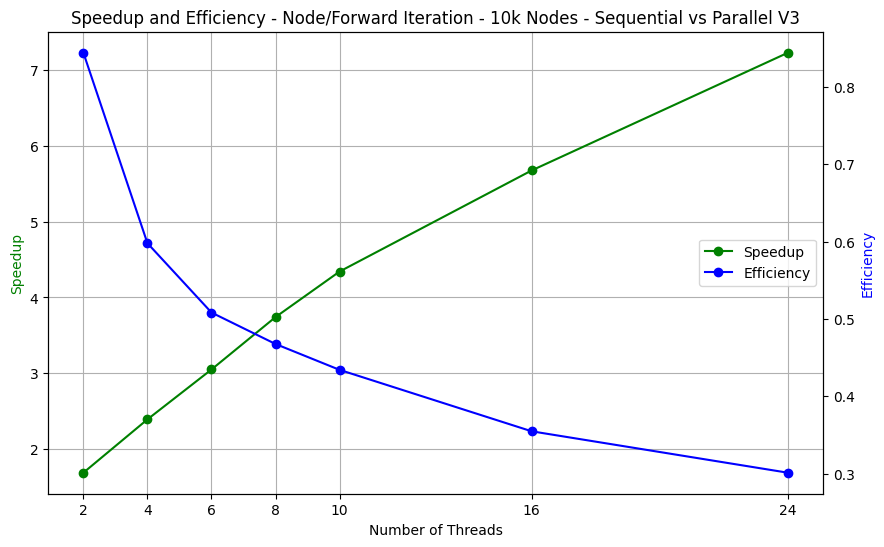

In [13]:
#chart for speedup and efficiency
speedup_efficiency_df = pd.DataFrame(speedup_efficiency_data)
print("Speedup and Efficiency DataFrame:")
print(speedup_efficiency_df)
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.plot(speedup_efficiency_df['NUM_THREADS'], speedup_efficiency_df['SPEEDUP'], 'g-o', label='Speedup')
ax2.plot(speedup_efficiency_df['NUM_THREADS'], speedup_efficiency_df['EFFICIENCY'], 'b-o', label='Efficiency')
ax1.set_xlabel('Number of Threads')
ax1.set_ylabel('Speedup', color='g')
ax2.set_ylabel('Efficiency', color='b')
plt.title('Speedup and Efficiency - Node/Forward Iteration - 10k Nodes - Sequential vs Parallel V3')
ax1.set_xticks(speedup_efficiency_df['NUM_THREADS'])
ax1.grid(True)
#union of legendd
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
#plt.savefig('./charts/node_forward_iteration_10k_nodes_speedup_efficiency.png')
plt.show()

CUDA Node IT V2 DataFrame:
   BLOCK_SIZE  TOTAL_DURATION_US
0           8                581
1          16                522
2          32                535
3          64                523
4         128                521
5         256                520
6         512                517


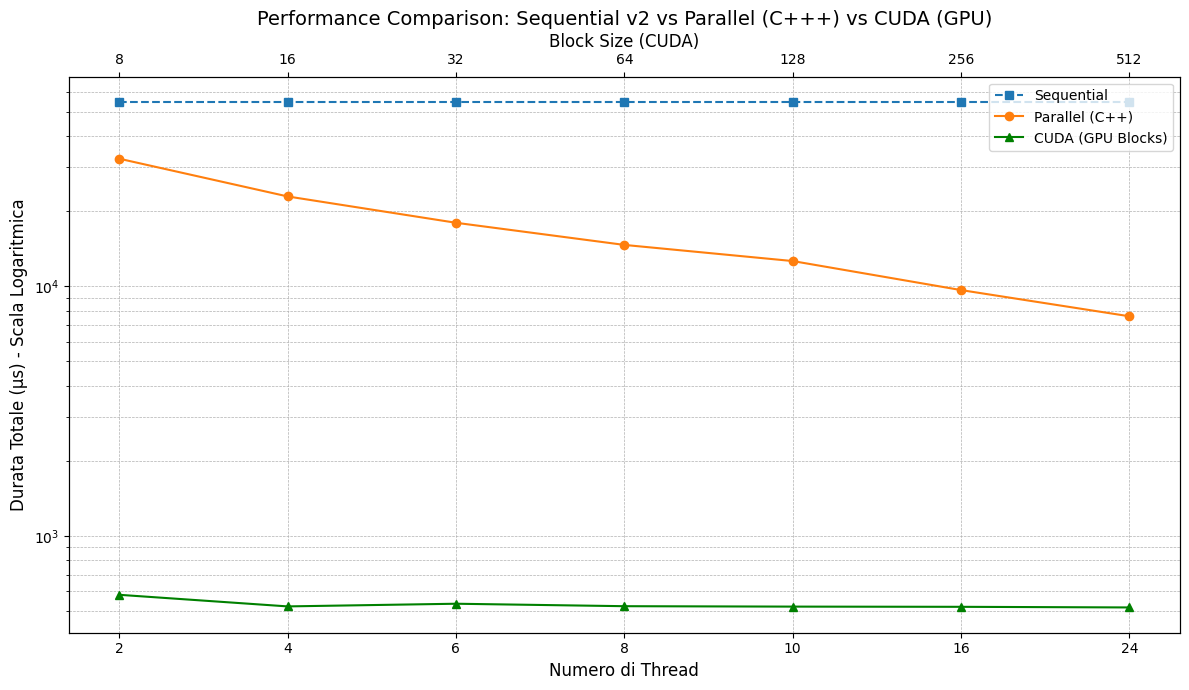

In [21]:
#load cuda data
desired_cols_CUDA = ['BLOCK_SIZE', 'TOTAL_DURATION_US']
cuda_node_it_v2_df = pd.read_csv(CUDA_NODE_IT_V2, usecols=desired_cols_CUDA)
print("CUDA Node IT V2 DataFrame:")
print(cuda_node_it_v2_df)


num_threads_list = [2, 4, 6, 8, 10, 16, 24]
num_blocks_list = [8, 16, 32, 64, 128, 256, 512]

# --- Preparazione Dati ---
# Crea una linea retta per i dati sequenziali usando la stessa lunghezza degli altri test
duration_straight_line = seq_node_it_v2_df['TOTAL_DURATION_US'].iloc[0]

seq_node_it_v2_df_extended = pd.DataFrame({
    'NUM_THREADS': num_threads_list,
    'TOTAL_DURATION_US': [duration_sttraight_line] * len(num_threads_list)
})
# Usiamo un indice comune per l'asse X. La sua lunghezza è data dal numero di test eseguiti.
x_axis_indices = range(len(num_threads_list))

# --- Creazione del Grafico ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# 1. Asse X inferiore per CPU (Threads)
ax1.set_xlabel('Numero di Thread', fontsize=12)
ax1.set_ylabel('Durata Totale (µs) - Scala Logaritmica', fontsize=12)

# Plotta i dati usando gli indici [0, 1, 2...] sull'asse X
ax1.plot(x_axis_indices, [duration_straight_line] * len(x_axis_indices), label='Sequential', marker='s', linestyle='--')
ax1.plot(x_axis_indices, parallel_node_it_v3_df['TOTAL_DURATION_US'], label='Parallel (C++)', marker='o')

# Imposta le etichette dell'asse X inferiore in modo che mostrino il numero di thread
ax1.set_xticks(x_axis_indices)
ax1.set_xticklabels(num_threads_list)
ax1.tick_params(axis='y')

# 2. Asse X superiore per GPU (Blocchi)
ax2 = ax1.twiny() # Crea un secondo asse X che condivide l'asse Y
ax2.set_xlabel('Block Size (CUDA)', fontsize=12)

# Plotta i dati CUDA sempre usando gli stessi indici [0, 1, 2...]
ax2.plot(x_axis_indices, cuda_node_it_v2_df['TOTAL_DURATION_US'], label='CUDA (GPU Blocks)', marker='^', color='green')

# Imposta le etichette dell'asse X superiore in modo che mostrino il numero di blocchi
ax2.set_xticks(x_axis_indices)
ax2.set_xticklabels(num_blocks_list)

# --- Finalizzazione Grafico ---
plt.title('Performance Comparison: Sequential v2 vs Parallel (C+++) vs CUDA (GPU)', fontsize=14)
plt.yscale('log') # La scala logaritmica è ottima per confrontare ordini di grandezza diversi
ax1.grid(True, which="both", ls="--", linewidth=0.5)

# Gestione unificata delle legende da entrambi gli assi
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

fig.tight_layout() # Aggiusta il layout per evitare sovrapposizioni
plt.show()




CUDA Speedup and Efficiency DataFrame:
   NUM_THREADS     SPEEDUP  EFFICIENCY
0            8   94.330465   11.791308
1           16  104.992337    6.562021
2           32  102.441121    3.201285
3           64  104.791587    1.637369
4          128  105.193858    0.821827
5          256  105.396154    0.411704
6          512  106.007737    0.207046


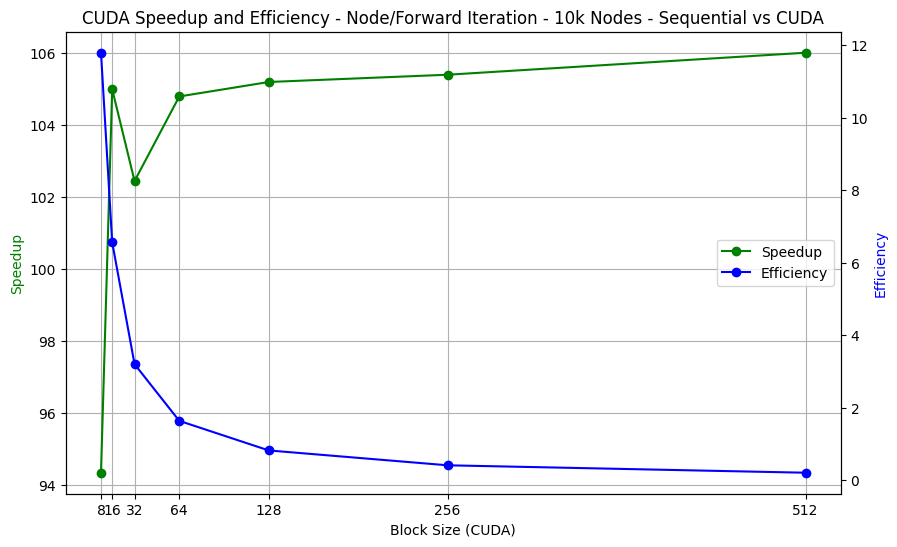

In [24]:
#cuda vs sequential v2 - speedup and efficiency

speedup_efficiency_data = {'NUM_THREADS': [],
    'SPEEDUP': [],
    'EFFICIENCY': []}

for index, row in cuda_node_it_v2_df.iterrows():
    blockSize = row['BLOCK_SIZE']
    cuda_duration = row['TOTAL_DURATION_US']
    sequential_duration = duration_straight_line
    speedup = sequential_duration / cuda_duration
    efficiency = speedup / blockSize
    speedup_efficiency_data['NUM_THREADS'].append(blockSize)
    speedup_efficiency_data['SPEEDUP'].append(speedup)
    speedup_efficiency_data['EFFICIENCY'].append(efficiency)

#chart for speedup and efficiency
speedup_efficiency_df = pd.DataFrame(speedup_efficiency_data)
print("CUDA Speedup and Efficiency DataFrame:")
print(speedup_efficiency_df)
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.plot(speedup_efficiency_df['NUM_THREADS'], speedup_efficiency_df['SPEEDUP'], 'g-o', label='Speedup')
ax2.plot(speedup_efficiency_df['NUM_THREADS'], speedup_efficiency_df['EFFICIENCY'], 'b-o', label='Efficiency')
ax1.set_xlabel('Block Size (CUDA)')
ax1.set_ylabel('Speedup', color='g')
ax2.set_ylabel('Efficiency', color='b')
plt.title('CUDA Speedup and Efficiency - Node/Forward Iteration - 10k Nodes - Sequential vs CUDA')
ax1.set_xticks(speedup_efficiency_df['NUM_THREADS'])
ax1.grid(True)
#union of legendd
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
#plt.savefig('./charts/node_forward_iteration_10k_nodes_cuda_speedup_efficiency.png')
plt.show()



Sequential Node IT V2 DataFrame:
   TOTAL_DURATION_US
0              54806
   NUM_THREADS  TOTAL_DURATION_US
0            2              54806
1            4              54806
2            6              54806
3            8              54806
4           10              54806
5           16              54806
6           24              54806


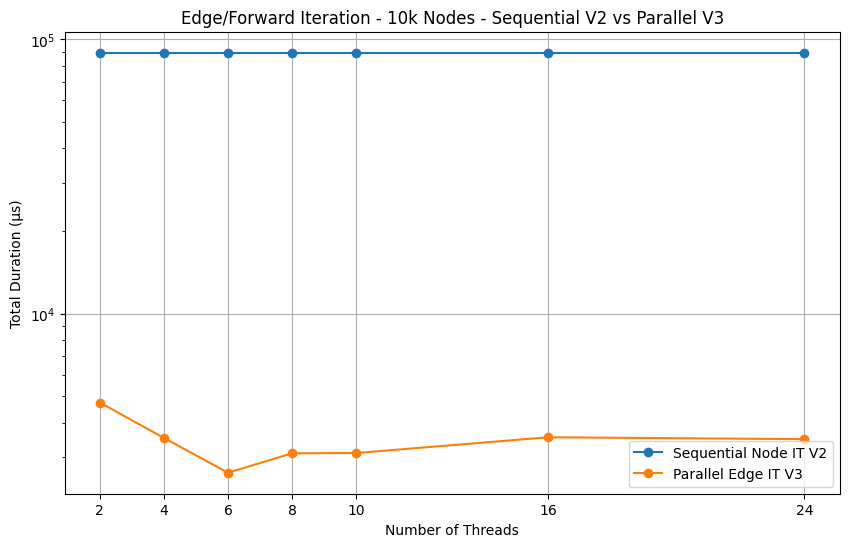

In [40]:
#chart multiseries - Node
SEQ_EDGE_IT_V2 = CSV_DIR + "seq_edge_it_v2/graph_10k_RTX_4060_M.csv"
PARALLEL_EDGE_IT_V3 = CSV_DIR + "parallel_edge_it_manual_threads_v3/graph_10k_INTEL_I7_14650HX.csv"

desired_cols = ['NUM_THREADS', 'TOTAL_DURATION_US']
fig = plt.figure(figsize=(10, 6))
seq_edge_it_v2_df = pd.read_csv(SEQ_EDGE_IT_V2, usecols=['TOTAL_DURATION_US'])
parallel_edge_it_v3 = pd.read_csv(PARALLEL_EDGE_IT_V3, usecols=desired_cols)

print("Sequential Node IT V2 DataFrame:")
print(seq_node_it_v2_df)
#FOR sequential put a straight line
num_threads_list = [2, 4, 6, 8, 10, 16, 24]
duration_sttraight_line = seq_edge_it_v2_df['TOTAL_DURATION_US'].iloc[0]
seq_edge_it_v2_df_extended = pd.DataFrame({
    'NUM_THREADS': num_threads_list,
    'TOTAL_DURATION_US': [duration_sttraight_line] * len(num_threads_list)
})
print(seq_node_it_v2_df_extended)
plt.plot(seq_edge_it_v2_df_extended['NUM_THREADS'], seq_edge_it_v2_df_extended['TOTAL_DURATION_US'], label='Sequential Node IT V2', marker='o')
plt.plot(parallel_edge_it_v3['NUM_THREADS'], parallel_edge_it_v3['TOTAL_DURATION_US'], label='Parallel Edge IT V3', marker='o')
plt.title('Edge/Forward Iteration - 10k Nodes - Sequential V2 vs Parallel V3')
plt.xlabel('Number of Threads')
plt.ylabel('Total Duration (µs)')
plt.legend()
plt.xticks(parallel_edge_it_v3['NUM_THREADS'])
plt.yscale('log')
plt.grid(True)
plt.savefig('./charts/edge_forward_iteration_10k_nodes_comparison.png')
plt.show()